# Poređenje rezultata različitih modela simulacije

## 1. Postavka zadatka

Simulirati promenu temperature u jednodimenzionalnom štapu dužine $L$ metara u trajanju od $t$ sekundi pod sledećim uslovima:
* Temperatura na levoj strani je konstantnih 10 stepeni Celzijusa
* Temperatura na desnoj strani je konstantnih 10 stepeni Celzijusa
* Temperatura na početku simulacije je konstantnih 0 stepeni Celzijusa u celom štapu 
* Difuziona konstanta $\alpha = 0.005$

Kreirati različite modele simulacije, modele zasnovane na klasičnim numeričkim metodama (metoda konačnih razlika i metoda konačnih elemenata) kao i modele zasnovane na neuronskim mrežama (data driven, fizičke kao i hibridne neuronske mreže).

Na kraju vizuelizovati i uporediti učinak različitih modela u različitim situacijama.

In [ ]:
L = 1.
granicaLevo = 10.
granicaDesno = 10.
pocetnaTemperatura = 0.
alpha = 0.005
tMax = 70.


# 2. Razvojno okruženje

## 2.1. Uvoz potrebnih biblioteka

Za izradu projekta koristićemo sledeće biblioteke:

* Numpy - matrični račun
* Matplotlib - vizuelizacija rezultata
* Pandas - obrada podataka
* PyTorch - treniranje neuronskih mreža
* SciPy - biblioteka za rešavanje matrične jednačine

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
import scipy.linalg

## 2.2 Pomoćne funkcije za skaliranje podataka

Kod neuronskih mreža (a naročito kod onih koje koriste više funkcija grešaka kao što su PINNs), izuzetno je bitno sve podatke skalirati (transformisati u interval od 0 do 1). Na ovaj način garantujemo da će svi faktori u obučavanju neuronske mreže biti podjednako bitni.

U nastavku ćemo definisati funkcije za skaliranje svih vrednosti koje će se pojavljivati u našim neuronskim mrežama (vreme, dužina, temperatura, difuziona konstanta). Takođe, za temperaturu ćemo definisati i metodu koja će iz skaliranog oblika vraćati vrednost u originalni oblik; ova metoda će biti korisna u procesu testiranja.

Skaliranje veličine x ćemo ostvariti deljenjem vrednosti sa maksimalnom vrednošću x (dužina štapa). Analogno skaliranje vremena ćemo ostvariti deljenjem sa maksimalnom vrednošću vremena, a temperaturu deljenjem sa maksimalnom vrednošću leve i desne granične vrednosti, kao i početnog uslova, uz pretpostavku da temperatura neće izlaziti iz datog opsega.

Kako smo skalirali sve kontinualne vrednosti, dobijamo novu jednačinu toplote u kojoj je potrebno da faktore skaliranja uračunamo u vrednost $\alpha$.

In [3]:
x_scale_const = 1.
t_scale_const = 60.
T_scale_const = float(max(granicaLevo, granicaDesno, pocetnaTemperatura))

def skalirajX(X):
    X /= x_scale_const
    return X
def skalirajt(t):
    t /= t_scale_const
    return t
def skalirajT(T):
    T /= T_scale_const
    return T
def deskalirajT(T_skalirano):
    T_skalirano *= T_scale_const
    return T_skalirano
def skalirajAlfa(alpha):
    return alpha * (t_scale_const / x_scale_const**2)

Dodaćemo i metodu koja će generisati analitičko rešenje, ovo rešenje će biti referentna tačka poređenja za sve buduće modele.

In [39]:
def analiticko_resenje(nt=None, nx=100, broj_clanova=200):
    """
    Vraća analitičko rešenje jednačine toplote kao matricu (nt, nx).
    
    Koristi Fourijev red:
        T(x,t) = T_b + sum_{n=1,3,5,...} [ -4*(T_b - T_0)/(n*pi) * sin(n*pi*x/L) * exp(-alpha*(n*pi/L)^2 * t) ]
    """
    if nt is None:
        nt = int(tMax / (0.5 * (L / 99)**2 / alpha))  # isti broj koraka kao FDM sa 100 tačaka

    x = np.linspace(0, L, nx)
    t = np.linspace(0, tMax, nt)

    X, T_grid = np.meshgrid(x, t)   # oblika (nt, nx)

    T = np.full_like(X, granicaLevo, dtype=float)

    for n in range(1, broj_clanova * 2, 2):   # samo neparni članovi
        prostorni_deo  = np.sin(n * np.pi * X / L)
        vremenski_deo  = np.exp(-alpha * (n * np.pi / L)**2 * T_grid)
        T += (-4 * (granicaLevo - pocetnaTemperatura) / (n * np.pi)) * prostorni_deo * vremenski_deo

    # Osiguranje graničnih uslova (Gibsov fenomen na rubovima)
    T[:, 0]  = granicaLevo
    T[:, -1] = granicaDesno

    return T, x, t

## 2.3 Metoda za vizuelizaciju dobijenih rešenja

Kako će nam u nastavku trebati metode za vizuelizaciju i poređenje resenja, kreiraćemo jedinstvenu metodu koju ćemo pozivati u ostatku koda, navedena metoda kreiraće dva grafika, mapu promene temperature, kao i grafike temperatura u određenom broju diskretnih momenata.

In [ ]:
def vizuelizuj_temperaturu(T, x=None, t=None, dt=None,
                           naslov="Raspodela temperature u štapu",
                           putanja_do_cuvanja=None,
                           broj_profila=7,
                           L=L, tMax=tMax):
    nt, nx = T.shape

    # Podrazumevane prostorne koordinate
    if x is None:
        x = np.linspace(0, L, nx)

    # Podrazumevane vremenske koordinate
    if t is None:
        if dt is not None:
            t = np.arange(nt) * dt
        else:
            t = np.arange(nt)  # prikazujemo indeks koraka

    # Kreiranje grafika sa dva podgrafika
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={'width_ratios': [2, 1]})
    fig.suptitle(naslov, fontsize=16, fontweight='bold')

    #Heatmap
    if dt is not None or t is not None and np.ptp(t) > nt-1:
        extent = [x[0], x[-1], t[0], t[-1]]
    else:
        extent = [x[0], x[-1], 0, nt-1]
    
    im = ax1.imshow(T, aspect='auto', origin='lower', extent=extent,
                    cmap='inferno', interpolation='bilinear')
    ax1.set_xlabel('Položaj x [m]')
    ax1.set_ylabel('Vreme [s]' if (dt is not None or (t is not None and np.ptp(t) > nt-1)) else 'Vremenski korak')
    ax1.set_title('Evolucija temperature')
    plt.colorbar(im, ax=ax1, label='Temperatura [°C]')

    # Temperaturni profili u odabranim trenucima
    # Biramo ravnomerno raspoređene indekse vremenskih koraka
    indeksi = np.linspace(0, nt-1, min(broj_profila, nt), dtype=int)
    boje = plt.cm.viridis(np.linspace(0, 1, len(indeksi)))

    for idx, boja in zip(indeksi, boje):
        vreme = t[idx] if t is not None else idx
        ax2.plot(x, T[idx, :], color=boja, linewidth=2,
                 label=f't = {vreme:.2f} s' if isinstance(vreme, float) else f'Korak {vreme}')
    
    ax2.set_xlabel('Položaj x [m]')
    ax2.set_ylabel('Temperatura [°C]')
    ax2.set_title('Temperaturni profili')
    ax2.legend(loc='best', fontsize='small')
    ax2.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    if putanja_do_cuvanja:
        plt.savefig(putanja_do_cuvanja, dpi=150, bbox_inches='tight')
    plt.show()

Gore kreirana metoda koristi matrični oblik vrednosti za vizuelizaciju, ovaj format je povoljan za numeričke metode, ipak metode zasnovane na neuronskim mrežama će rezultate vraćati u obliku tenzora. Zbog toga kreiraćemo funkciju koja za prosleđeni model neuronske mreže vraća identičan format podataka kao i numeričke metode.

In [ ]:
def priprema_podataka(model, nt_custom=None):
    model = model.cpu()  # Osiguravamo da je model na CPU-u
    nx_viz = 100      # Broj tačaka na štapu za prikaz
    nt_viz = nt_custom if nt_custom is not None else 200

    # Generisanje x i t nizova
    x_viz = np.linspace(0, L, nx_viz)
    t_viz = np.linspace(0, tMax, nt_viz)

    X_grid, T_grid = np.meshgrid(x_viz, t_viz)

    # Ravnanje u 1D nizove i spajanje u kolone (kako bi dobili oblik (N, 2))
    X_test = np.column_stack((skalirajX(X_grid.flatten()), skalirajt(T_grid.flatten())))

    # Pretvaranje u PyTorch tenzor
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

    # Prebacujemo model u mod za evaluaciju (isključuje gradient tracking radi brzine)
    model.eval()

    with torch.inference_mode():
        # Model predviđa temperaturu za sve tačke odjednom
        T_pred_tensor = model(X_test_tensor)

    # Pretvaramo rezultat nazad u NumPy niz
    T_pred_flat = T_pred_tensor.numpy()

    # Vraćamo izravnani niz nazad u 2D matricu dimenzija (nt_viz, nx_viz)
    T_matrica_predikcija = deskalirajT(T_pred_flat.reshape(nt_viz, nx_viz))

    return T_matrica_predikcija, x_viz, t_viz

Zbog potrebe za poređenjem različitih modela, kreiraćemo i funkciju koja će primati listu proračuna koje su izvršile različite metode a zatim kreirati grid grafika u kojima će svaki grafik odgovarati tačno jednom proračunu, ovaj format će biti idealan za dalje poređenje rezultata.

In [ ]:
def vizuelizuj_grid_temperatura(lista_T, naslovi=None, redova=4, kolona=2, 
                               x=None, dt=None, L=1.0, putanja_do_cuvanja=None):
    
    broj_simulacija = len(lista_T)
    
    # Kreiramo figuru (Ovo sprečava UnboundLocalError)
    fig = plt.figure(figsize=(18, 5 * redova))
    
    # Kreiramo glavnu mrežu (GridSpec)
    gs_main = fig.add_gridspec(redova, kolona, hspace=0.4, wspace=0.3)
    
    if naslovi is None:
        naslovi = [f"Simulacija {i+1}" for i in range(broj_simulacija)]

    for i, T in enumerate(lista_T):
        if i >= redova * kolona:
            break  # Ne crtamo više nego što imamo mesta u gridu
            
        nt, nx = T.shape
        if x is None:
            prostorni_x = np.linspace(0, L, nx)
        else:
            prostorni_x = x

        # Kreiramo pod-mrežu unutar trenutnog slota (1 red, 2 kolone)
        ax_pair = gs_main[i].subgridspec(1, 2, width_ratios=[1.5, 1])
        
        # Dodeljujemo ose
        ax1 = fig.add_subplot(ax_pair[0, 0])
        ax2 = fig.add_subplot(ax_pair[0, 1])

        vreme_oznaka = "Vreme [s]" if dt is not None else "Korak"
        t_max = (nt - 1) * (dt if dt else 1)
        extent = [prostorni_x[0], prostorni_x[-1], 0, t_max]
        
        im = ax1.imshow(T, aspect='auto', origin='lower', extent=extent,
                        cmap='inferno', interpolation='bilinear')
        ax1.set_title(f"{naslovi[i]}\n(Evolucija)", fontsize=10)
        ax1.set_xlabel('x [m]')
        ax1.set_ylabel(vreme_oznaka)
        
        # Dodavanje colorbar-a sa desne strane heatmap-e
        cbar = fig.colorbar(im, ax=ax1)
        cbar.set_label('°C', size=8)

        indeksi = np.linspace(0, nt - 1, 5, dtype=int) 
        boje = plt.cm.viridis(np.linspace(0, 1, len(indeksi)))
        
        for idx, boja in zip(indeksi, boje):
            v_vrednost = idx * dt if dt else idx
            ax2.plot(prostorni_x, T[idx, :], color=boja, linewidth=1.5,
                     label=f't={v_vrednost:.1f}' if dt else f'k={idx}')
        
        ax2.set_title("Temperaturni profili", fontsize=10)
        ax2.set_xlabel('x [m]')
        ax2.set_ylabel('T [°C]')
        ax2.legend(fontsize='x-small', loc='upper right')
        ax2.grid(True, linestyle='--', alpha=0.4)

    # Podešavanje margina da naslovi ne udaraju u ivice
    plt.subplots_adjust(top=0.95, bottom=0.05, left=0.05, right=0.95)

    if putanja_do_cuvanja:
        plt.savefig(putanja_do_cuvanja, dpi=150, bbox_inches='tight')
    
    plt.show()

Kreiraćemo metodu za iscrtavanje grafika prikaza promene temperature na sredini štapa za svaki od modela, na ovaj način, zanemarićemo koliziju graničnih i početnih uslova i moći da posmatramo samo fizičku promenu temperature u jednoj tački. Stoga, zaključićemo da li je promena glatka i fizički konzistentna.

Pošto želimo da poredimo efikasnost svih metode u odnosu na analitičko rešenje, namestićemo da nam x osa zapravo predstavlja analitičko rešenje, na taj način ćemo dobiti grafik odstupanja svih rešenja od analitičkog.

In [29]:
def vizuelizuj_vrednosti_na_sredini(metodaKonacnihRazlika=None, metodaKonacnihElemenata=None, 
                                    T1=None, T2=None, T3=None, T4=None, T5=None,
                                    tMin=None, tMax_prikaz=None, crtajNumericke=True, label = None):

    # --- Analitičko rešenje ---
    T_analiticko, _, t_analiticko_orig = analiticko_resenje()
    sredina_analiticko = T_analiticko.shape[1] // 2

    # --- Ekstrakcija numeričkih podataka ---
    T_fdm = metodaKonacnihRazlika.T_matrica
    dt_fdm = metodaKonacnihRazlika.dt

    T_fem = metodaKonacnihElemenata.T_matrica
    dt_fem = metodaKonacnihElemenata.dt

    sredina_fdm = T_fdm.shape[1] // 2
    sredina_fem = T_fem.shape[1] // 2

    t_fdm_orig = np.arange(T_fdm.shape[0]) * dt_fdm
    t_fem_orig = np.arange(T_fem.shape[0]) * dt_fem

    # --- Dinamičko određivanje granica vremenske ose ---
    t_min_val = tMin if tMin is not None else 0
    
    # Skupljamo maksimalna vremena iz svih dostupnih modela
    lista_krajnjih_vremena = [t_fdm_orig[-1], t_fem_orig[-1]]
    for T_matrica in [T1, T2, T3, T4, T5]:
        if T_matrica is not None:
            lista_krajnjih_vremena.append((T_matrica.shape[0] - 1) * dt_fdm)
            
    t_max_val = tMax_prikaz if tMax_prikaz is not None else max(lista_krajnjih_vremena)

    # --- Funkcija za interpolaciju analitičkog rešenja ---
    def izracunaj_gresku(t_orig, T_kolona):
        maska = (t_orig >= t_min_val) & (t_orig <= t_max_val)
        t_filtrirano = t_orig[maska]
        T_filtrirano = T_kolona[maska]
        
        # Interpolacija analitičkog rešenja na vremensku skalu t_filtrirano
        T_analiticko_interp = np.interp(t_filtrirano, t_analiticko_orig, T_analiticko[:, sredina_analiticko])
        
        return t_filtrirano, T_filtrirano - T_analiticko_interp

    # Računanje odstupanja za uvek prisutne numeričke metode
    t_fdm, err_fdm = izracunaj_gresku(t_fdm_orig, T_fdm[:, sredina_fdm])
    t_fem, err_fem = izracunaj_gresku(t_fem_orig, T_fem[:, sredina_fem])

    # --- Iscrtavanje ---
    fig, ax = plt.subplots(figsize=(12, 7))

    # Referentna linija (Analitičko rešenje kao nula)
    ax.axhline(y=0, color='black', linewidth=1, zorder=1)

    # Odstupanja numeričkih metoda
    if crtajNumericke:
        ax.plot(t_fdm, err_fdm, color='red',   linewidth=1, linestyle='-', label='Δ Metoda konačnih razlika')
        ax.plot(t_fem, err_fem, color='green', linewidth=1, linestyle='-', label='Δ Metoda konačnih elemenata')

    # Odstupanja neuronskih mreža (iscrtavaju se samo ako su prosleđene)
    if T1 is not None:
        t_nn, err_T1 = izracunaj_gresku(np.arange(T1.shape[0]) * dt_fdm, T1[:, T1.shape[1] // 2])
        ax.plot(t_nn, err_T1, color='blue', linewidth=1, linestyle='-', label='Δ Data-Driven (šum 0.1)')
        
    if T2 is not None:
        t_nn, err_T2 = izracunaj_gresku(np.arange(T2.shape[0]) * dt_fdm, T2[:, T2.shape[1] // 2])
        ax.plot(t_nn, err_T2, color='gold', linewidth=1, linestyle='-', label='Δ Data-Driven (šum 0.5)')
        
    if T3 is not None:
        t_nn, err_T3 = izracunaj_gresku(np.arange(T3.shape[0]) * dt_fdm, T3[:, T3.shape[1] // 2])
        ax.plot(t_nn, err_T3, color='purple', linewidth=1, linestyle='-', label='Δ PINN')
        
    if T4 is not None:
        t_nn, err_T4 = izracunaj_gresku(np.arange(T4.shape[0]) * dt_fdm, T4[:, T4.shape[1] // 2])
        ax.plot(t_nn, err_T4, color='red', linewidth=1, linestyle='-', label='Δ Hibridna (šum 0.1)')
        
    if T5 is not None:
        t_nn, err_T5 = izracunaj_gresku(np.arange(T5.shape[0]) * dt_fdm, T5[:, T5.shape[1] // 2])
        ax.plot(t_nn, err_T5, color='green', linewidth=1, linestyle='-', label='Δ Hibridna (šum 0.5)')

    # Oznaka kraja treninga
    t_kraj_treninga = 55
    if t_min_val <= t_kraj_treninga <= t_max_val:
        ax.axvline(x=t_kraj_treninga, color='red', linewidth=1.2, linestyle=':', alpha=0.8,
                   label='Kraj trening intervala (t=55 s)')

    ax.set_xlim(t_min_val, t_max_val)
    ax.set_xlabel('Vreme [s]', fontsize=12)
    ax.set_ylabel('Odstupanje od analitičkog rešenja [°C]', fontsize=12)

    if label is None:
        naslov = 'Odstupanje (Greška) modela u odnosu na analitičko rešenje'
    else:
        naslov = label
    
    if tMin is not None or tMax_prikaz is not None:
        naslov += f'\n(prikaz: {t_min_val:.1f}s – {t_max_val:.1f}s)'
    ax.set_title(naslov, fontsize=14, fontweight='bold')

    ax.legend(loc='best', fontsize=9, framealpha=0.85, ncol=2)
    ax.grid(True, linestyle='--', alpha=0.5)

    # Dodatak: simetrične granice y-ose radi bolje preglednosti
    y_abs_max = max(abs(ax.get_ylim()[0]), abs(ax.get_ylim()[1]))
    ax.set_ylim(-y_abs_max * 1.1, y_abs_max * 1.1)

    plt.tight_layout()
    plt.show()

## 3. Numerički modeli simulacije

Numerički modeli podrazumevaju primenu numeričkih metoda aproksimacije parcijalnih izvoda u cilju brzog i jednostavnog računarskog rešavanja parcijalnih diferencijalnih jednačina, ove metode su zaživele sedamdesetih godina prošlog veka, iako metode omogućavaju približno egzaktno rešavanje složenih diferencijalnih jednačina ove metode su pokazale dve ključne slabosti:
1. Vreme potrebno za proračun - u složenim sistemima koji imaju veliki broj različitih uticaja, računanje može potrajati i do nekoliko dana
2. Nemogućnost dodavanja realnih podataka - u prirodi ne postoje idealni materijali i idealne fizičke pojave zbog toga događaji opisan samo diferencijalnom jednačinom bez dodatnih izmerenih podataka često ne mogu poslužiti kao realno rešenje

### 3.1 Metoda konačnih razlika

Metoda konačnih razlika je numerička metoda rešavanja parcijalnih diferencijalnih jednačina koja se zasniva na jednoj od sledećih aproksimacija prvog izvoda:

$$ f'(x) = \frac{f(x+h) - f(x)}{h} \tag{1} $$
<p align="center"><i>Slika 1: Aproksimacija unapred</i></p>

$$ f'(x) = \frac{f(x) - f(x-h)}{h} \tag{2} $$
<p align="center"><i>Slika 2: Aproksimacija unazad</i></p>

$$ f'(x) = \frac{f(x+h) - f(x-h)}{2h} \tag{3} $$
<p align="center"><i>Slika 3: Centralna razlika</i></p>

Analogno se definiše aproksimacija drugog izvoda na sledeći način:
$$ f''(x) = \frac{f'(x+h) - f'(x)}{h} = \frac{\frac{f(x+h)-f(x)}{h} - \frac{f(x)-f(x-h)}{h}}{h} = \frac{f(x+h) -2f(x) + f(x-h)}{h^2}   \tag{4} $$
<p align="center"><i>Slika 4: Aproksimacija drugog izvoda metodom centralnih razlika</i></p>

#### 3.1.1. Primena u jednačini toplote

Polazeći od početne jednačine toplote oblika $ \frac{\delta T}{\delta t} = \alpha \frac{\delta^2 T}{\delta x^2}$ i primenom metode konačnih razlika dobijamo jednačinu: 
$$ \frac{T(x, t+ \Delta t) - T(x, t)}{\Delta t} = \alpha * \frac{T(x+ \Delta x,  t) -2T(x, t) + T(x - \Delta x, t)}{\Delta x^2} $$

Kako nam je potrebno da računamo temperaturu u sledećem momentu, dobijamo jednačinu: 

$$ T(x, t+ \Delta t) = \frac{\Delta t}{\Delta x^2} * \alpha * (T(x+ \Delta x,  t) -2T(x, t) + T(x - \Delta x, t)) + T(x, t) $$

#### 3.1.2. Implementacija

Kreiraćemo klasu FiniteDifferenceSimulation, ovoj klasi će biti prosleđen broj tačaka na štapu čije će temperature biti simulirane, na osnovu toga biće izračunato dx (razdaljina između tačaka na štapu) kao i dt (razlika između diskretnih vremenskih trenutaka simulacije) uzevši u obzir zakon stabilnosti $\frac{\alpha \Delta t}{\Delta x^2} \le 0.5$.<br>
Unutar metode simulacija, iterativnim korakom će se računati temperatura u svakom sledećem diskretnom trenutku za svaku tačku, radi optimizacije koda koristićemo standardizovan python način za iterativno računanje, vektorizaciju.

In [9]:
class FiniteDifferenceSimulation:
    def __init__(self, brTacaka):
        self.konstantaStabilnosti = 0.5
        self.brTacaka = brTacaka
        self.dx = L/ (brTacaka-1)
        
        self.dt = self.konstantaStabilnosti * self.dx**2 / alpha
        self.nt = int(tMax / self.dt)
        
        self.x = np.linspace(0, L, brTacaka)

        self.coeff = alpha * self.dt / self.dx**2
        self.T_matrica =self.simulacija()
    
    def simulacija(self):
        T_matrica = np.zeros((self.nt, self.brTacaka))
    
        # Postavljanje početnog uslova za t=0
        T_matrica[0, :] = pocetnaTemperatura
        T_matrica[:, 0] = granicaLevo
        T_matrica[:, -1] = granicaDesno

        

        T_curr = T_matrica[0, :].copy()
        for n in range(self.nt - 1):
            T_curr[1:-1] = T_curr[1:-1] + self.coeff * (T_curr[2:] - 2*T_curr[1:-1] + T_curr[:-2])
            T_curr[0] = granicaLevo      # osiguranje graničnih uslova na T_curr
            T_curr[-1] = granicaDesno
            T_matrica[n+1, :] = T_curr
            
        return T_matrica

### 3.2 Metoda konačnih elemenata

Osnovne prednosti ove metode u odnosu na prethodnu metodu su bezuslovna stabilnost (nije neophodno voditi računa o srazmeri vremenskog i prostornog koraka) kao i znatno veća stabilnost pri simulaciji kompleksnijih tela.
Ova numerička metoda deli kontinualni prostor na diskretan skup tačaka, svakoj tački dodeljuje zasebnu funkciju toplote, na ovaj način problem pronalaska prostorno kontinualne funkcije se svodi na pronalazak konačno mnogo funkcija u diskretnim tačkama. Formalno, ako štap podelimo na n tačaka ($x_1,x_2,...x_n$), tada:

$$T(x, t) \approx \sum_{j=1}^n N_j(x) T_j(t)$$

Pri čemu su funkcije $N_1, N_2,..., N_n$ date kao:
$$N_i(x) = 
\begin{cases} 
\frac{x - x_{i-1}}{x_i - x_{i-1}}, & x_{i-1} \le x \le x_i \\
\frac{x_{i+1} - x}{x_{i+1} - x_i}, & x_i < x \le x_{i+1} \\
0, & \text{inače}
\end{cases}$$

Ova metoda kompleksnu kontinualnu funkciju aproksimira skupom spojenih linearnih funkcija, zbog toga u ovoj metodi nije moguće primeniti drugi izvod (rešenje bi uvek bilo 0), zbog toga uvodi se pojam slabe forme diferencijalne jednačine.
Slaba forma podrazumeva množenje početne jednačine proizvoljnom prostornom test funkcijom a zatim integraciju celokupne jednačine po prostornom domenu. Kao test funkciju, po Galerkinovoj metodi, umesto proizvoljne funkcije koristićemo naše aproksimativne funkcije $N_i(x)$. Stoga početna jednačina se svodi na:
$$ \int_0^L N_i \left( \frac{\partial T}{\partial t} - \alpha \frac{\partial^2 T}{\partial x^2} \right) dx = 0 $$

Razdvajanjem integrala na dva zasebna integrala i primenom parcijalne integracije, uz pretpostavku konstantnih graničnih uslova, dobijamo jednačinu:
$$ \int_0^L N_i \frac{\partial T}{\partial t} dx + \alpha \int_0^L \frac{dN_i}{dx} \frac{\partial T}{\partial x} dx = 0 $$

Kako ovaj oblik ne poseduje drugi izvod funkcije, u njega možemo uvrstiti našu aproksimaciju funkcije T(x,t) i dobiti oblik:
$$ \sum_{j=1}^n \left( \int_0^L N_i N_j dx \right) \frac{dT_j}{dt} + \alpha \sum_{j=1}^n \left( \int_0^L \frac{dN_i}{dx} \frac{dN_j}{dx} dx \right) T_j = 0 $$
Pri čemu ova jednačina mora važiti za svako $N_i = {N_1, N_2, ... N_n}$ pa zapravo dobijamo sistem n diferencijalnih jednačina, dalje možemo uvesti smenu:

$$M_{ij}=\int_0^L N_i N_j dx \qquad K=\int_0^L \frac{dN_i}{dx} \frac{dN_j}{dx} dx$$

Matricu M nazivamo matricom mase, ona opisuje sposobnost materijala za prostiranje (razmenu) temperature
Matricu K nazivamo matrica krutosti, ona opisuje kako se temperatura kreće iz mesta više u mesto niže temperature.
Uvođenjem ove smene u početnu diferencijalnu jednačinu, i uvođenjem smene da ćemo temperaturu T tretirati kao vektor temperatura u različitim tačkama dobijamo:
$$ \mathbf{M} \mathbf{\frac{\delta T}{\delta t}} + \alpha \mathbf{K} \mathbf{T} = 0 \tag{5} $$

Ovaj oblik je zapravo matrična jednačina, rešavanjem ove jednačine dobijaćemo rešenje za temperaturu u sledećem momentu.

<b>Napomena</b> - pre nego što pređemo na implementaciju ove metode u jednodimenzionalnom sistemu bitno je napomenuti da se u složenijem prostoru (na primer u dve dimenzije) vrši podela prostora kao i u ovom jednostavnom slučaju, ipak za podelu se koriste složeniji elementi (npr. trouglovi ili kvadrati), dimenzije matrica zavise od broja elemenata koji međusobno utiču na promenu jednog zasebnog elementa

#### 3.1.2. Implementacija
Implementacija se oslanja na klasu FiniteElementSimulation. Prvi korak je formiranje lokalnih matrica za svaki element (segment štapa), koje se zatim sklapaju u globalnu matricu mase $M$ i globalnu matricu krutosti $K$. S obzirom na to da su funkcije oblika $N_i$ različite od nule samo na susednim elementima, ove matrice će biti retke (tridijagonalne u 1D slučaju), što značajno optimizuje proračun.Za diskretizaciju po vremenu koristićemo metodu unapred (kao kod metode konačnih razlika). U svakom vremenskom koraku, novi vektor temperatura $T^{t+\Delta t}$ dobija se rešavanjem sistema linearnih jednačina:$$ (\mathbf{M} + \Delta t \alpha \mathbf{K}) \mathbf{T}^{t+\Delta t} = \mathbf{M} \mathbf{T}^t $$Unutar simulacije, koristićemo numeričke biblioteke za rad sa matricama kako bismo efikasno rešili sistem u svakom koraku.

In [10]:
class FiniteElementSimulation:
    def __init__(self, brTacaka):
        self.brElemenata = brTacaka - 1
        self.brTacaka = brTacaka
        self.dx = L / self.brElemenata
        
        # Kod FEM-a možemo biti fleksibilniji sa dt, ali zadržimo sličan rezon
        self.dt = 0.01  # Možeš definisati na osnovu stabilnosti ili manuelno
        self.nt = int(tMax / self.dt)
        
        self.x = np.linspace(0, L, brTacaka)
        
        # Generisanje globalnih matrica
        self.K_global, self.M_global = self._sklopi_matrice()
        self.T_matrica = self.simulacija()

    def _sklopi_matrice(self):
        """Sklapanje globalne matrice krutosti (K) i matrice mase (M)"""
        K = np.zeros((self.brTacaka, self.brTacaka))
        M = np.zeros((self.brTacaka, self.brTacaka))
        
        # Lokalne matrice za jedan linearni element dužine dx
        # K_loc = (alpha/dx) * [[1, -1], [-1, 1]]
        # M_loc = (dx/6) * [[2, 1], [1, 2]]
        
        k_loc = (alpha / self.dx) * np.array([[1, -1], [-1, 1]])
        m_loc = (self.dx / 6.0) * np.array([[2, 1], [1, 2]])
        
        for i in range(self.brElemenata):
            # Ubacivanje lokalnih matrica u globalne (Assembly)
            K[i:i+2, i:i+2] += k_loc
            M[i:i+2, i:i+2] += m_loc
            
        return K, M

    def simulacija(self):
        T_matrica = np.zeros((self.nt, self.brTacaka))
        
        # Početni uslov
        T_curr = np.full(self.brTacaka, pocetnaTemperatura)
        T_matrica[0, :] = T_curr

        # Matrica sistema za Implicitni Euler: (M + dt*K) * T_next = M * T_curr
        A = self.M_global + self.dt * self.K_global
        
        for n in range(1, self.nt):
            # Desna strana jednačine
            B = self.M_global @ T_curr
            
            # Primena Dirichletovih graničnih uslova (fiksna temperatura na krajevima)
            # Modifikujemo matricu sistema da bi zadržali vrednosti na granicama
            A_boundary = A.copy()
            B_boundary = B.copy()
            
            # Leva granica (x=0)
            A_boundary[0, :] = 0; A_boundary[0, 0] = 1
            B_boundary[0] = granicaLevo
            
            # Desna granica (x=L)
            A_boundary[-1, :] = 0; A_boundary[-1, -1] = 1
            B_boundary[-1] = granicaDesno
            
            # Rešavanje sistema linearnih jednačina
            T_curr = scipy.linalg.solve(A_boundary, B_boundary)
            T_matrica[n, :] = T_curr
            
        return T_matrica

## 4. Simulacije upotrebom neuronskih mreža
### 4.1 Uvod

Neuronske mreže su najpopularnija metoda mašinskog učenja u simulacijama zato što omogućavaju pronalaženje funkcije koja najbolje opisuje zadate vrednosti, u odnosu na klasične numeričke metode, metoda simulacije obučavanjem neuronske mreže ima dve ključne prednosti:
1. Kontinualnost - za razliku od svih numeričkih metoda koje diskretizuju prostor, neuronske mreže kreiraju kontinulanu funkciju koja omogućava računanje temperature u proizvoljnoj tački.
2. Brzina - jednom obučena neuronska mreža izuzetno brzo računa izlaz za nove podatke 
3. Mogućnost uticaja na rešenje dodavanjem izmerenih podataka

### 4.2 Kreiranje neuronske mreže

Kreiraćemo jednu neuronsku mrežu, a u nastavku ćemo je obučavati pomoću različitih funkcija grešaka (loss functions), ova neuronska mreža će imati ulazni sloj sa dva neurona (x i t), zatim 5 skrivenih slojeva, redom sa 16, 64, 64, 64, 16 neurona, i na kraju jedan izlazni sloj (izlazna vrednost T). Između svaka dva sloja neuronske mreže upotrebićemo aktivacionu funkciju hiperbolički tangens, za ovu aktivacionu funkciju opredelili smo se zbog osobine beskonačne diferencijabilnosti koja je povoljna kod fizičkih neuronskih mreža.

In [ ]:
class NeuralNetwork(torch.nn.Module):
    def __init__(self):
        super(NeuralNetwork, self).__init__()
        self.model = torch.nn.Sequential(
            torch.nn.Linear(2, 16),
            torch.nn.Tanh(),
            torch.nn.Linear(16, 64),
            torch.nn.Tanh(),
            torch.nn.Linear(64, 64),
            torch.nn.Tanh(),
            torch.nn.Linear(64, 64),
            torch.nn.Tanh(),
            torch.nn.Linear(64, 16),
            torch.nn.Tanh(),
            torch.nn.Linear(16, 1),
        )
        
    def forward(self, x):
        return self.model(x)
    def izracunaj_ukupni_loss(self, lista_gresaka):
        ukupni_loss = 0
        for i, loss in enumerate(lista_gresaka):
            ukupni_loss += loss
        return ukupni_loss

### 4.3 Generisanje podataka

Sve neuronske mreže, bez obzira da li se radi o klasičnim ili fizički informisanim neuronskim mrežama, se oslanjaju na skupove podataka za treniranje.
U nastavku ćemo kreirati metode koje će generisati sve tipove podataka koji će nam biti potrebni za treniranje neuronskih mreža, to podrazumeva:
* Senzorska merenja - podaci koji će biti korišćeni za treniranje data driven neuronske mreže, svim podacima će biti pridodat šum sa normalnom raspodelom
* Granični uslovi - podaci o temperaturi na krajevima štapa koji će biti korišćeni u fizički informisanoj neuronskoj mreži
* Početni uslovi - podaci o temperaturi na početku simulacije
* Podaci za kontrolu ispoštovanosti fizike - jedini podaci koji neće biti generisani zajedno sa očekivanim izlazom - ovi podaci će biti korišćeni za kontrolu da li neuronska mreža poštuje fizičku jednačinu pri računanju

Sve metode će dobijati iste parametre, broj tačaka koje je potrebno generisati, dužinu štapa i vremenski interval generisanja, sve metode vratiće isti izlaz, uređene parove (x, t, T) pri čemu će funkcija za generisanje poštovanja fizike vratiti kao očekivani izlaz nulu, ovaj broj u praksi neće biti korišćen.

In [12]:
def generateSensorData(N, L, tMax, nivo_suma=0.2, broj_clanova_reda=50):
    x_merenja = np.random.uniform(0, L, N)
    t_merenja = np.random.uniform(0, tMax, N)
    
    T_tacno = np.full(N, 10.0) 
    
    
    for n in range(1, broj_clanova_reda * 2, 2):
        prostorni_deo = np.sin(n * np.pi * x_merenja / L)
        vremenski_deo = np.exp(-alpha * (n * np.pi / L)**2 * t_merenja)
        
        T_tacno -= (40.0 / (n * np.pi)) * prostorni_deo * vremenski_deo
        
    T_tacno = np.where(t_merenja == 0, 0.0, T_tacno)
    
    # Dodavanje šuma na tačne vrednosti (simulacija greške senzora)
    sum_senzora = np.random.normal(0, nivo_suma, N)
    T_mereno = T_tacno + sum_senzora

    x_skalirano = skalirajX(x_merenja)
    t_skalirano = skalirajt(t_merenja)
    T_skalirano = skalirajT(T_mereno)

    # Pakovanje u (x, t, T) format koji odgovara za treniranje neuronskih mreža
    dataset = np.column_stack((x_skalirano, t_skalirano, T_skalirano))

    return dataset

def createBoundaryConditions(N, L, tMax):
    # Nasumično biramo da li je tačka na levoj (0.0) ili desnoj (L) ivici
    x_merenja = np.random.choice([0.0, L], N)
    
    # Vreme je nasumično u celom intervalu
    t_merenja = np.random.uniform(0, tMax, N)
    
    # Ako je x=0, temperatura je granicaLevo, inače je granicaDesno
    T_mereno = np.where(x_merenja == 0.0, granicaLevo, granicaDesno)
    
    # Pakovanje u (x, t, T) format oblika (N, 3)

    x_skalirano = skalirajX(x_merenja)
    t_skalirano = skalirajt(t_merenja)
    T_skalirano = skalirajT(T_mereno)
    dataset = np.column_stack((x_skalirano, t_skalirano, T_skalirano))
    
    return dataset


def createBeginingCondition(N, L, tMax, pocetnaTemperatura=0.0):
    # Prostor je nasumičan duž celog štapa
    x_merenja = np.random.uniform(0, L, N)
    
    # Vreme je svuda tačno 0
    t_merenja = np.zeros(N)
    
    # Temperatura je svuda početna
    T_mereno = np.full(N, pocetnaTemperatura, dtype=float)
    
    # Pakovanje u (x, t, T) format oblika (N, 3)
    x_skalirano = skalirajX(x_merenja)
    t_skalirano = skalirajt(t_merenja)
    T_skalirano = skalirajT(T_mereno)
    dataset = np.column_stack((x_skalirano, t_skalirano, T_skalirano))
    
    return dataset


def createPDEData(N, L, tMax):
    # Nasumične tačke u prostoru i vremenu (unutrašnjost domena)
    x_merenja = np.random.uniform(0, L, N)
    t_merenja = np.random.uniform(0, tMax, N)
    
    # Za PDE tačke (kolokacione tačke), mi NE ZNAMO temperaturu. 
    T_mereno = np.zeros(N)
    
    # Pakovanje u (x, t, T) format oblika (N, 3)
    x_skalirano = skalirajX(x_merenja)
    t_skalirano = skalirajt(t_merenja)
    T_skalirano = skalirajT(T_mereno)
    dataset = np.column_stack((x_skalirano, t_skalirano, T_skalirano))
    
    return dataset

#### 4.4 Funkcije greške

U našim neuronskim mrežama razlikujemo dva tipa greški:

* Data loss - nastaje kada za određenu tačku znamo očekivanu vrednost za T, potrebno je uporediti pravu i predviđenu vrednost - za poređenje koristićemo MSE loss
* Physical loss - nastaje kod fizički informisanih neuronskih mreža, u ovim situacijama mi ne znamo koja je očekivana vrednost za T, ali znamo koju jednačinu naš model mora ispoštovati, jednačinu ćemo zapisati u obliku $\frac{\delta T}{\delta t} - \alpha \frac{\delta^2 T}{\delta x^2} = 0$ dakle ako je fizika ispoštovana, izraz će biti jednak nuli, zbog toga ćemo računati MSE loss za dobijenu vrednost izraza i nulu

U nastavku se nalaze funkcije za računanje ova dva tipa greški

In [13]:
def dataLoss(model, data, target):
    # Mreža predviđa temperature za date x i t
    T_pred = model(data)
    
    # Koristimo klasičnu srednju kvadratnu grešku (MSE)
    mse = torch.nn.MSELoss()
    loss = mse(T_pred, target)
    
    return loss


def physicalLoss(model, data, target=None):
    x = data[:, 0:1].clone().requires_grad_(True)
    t = data[:, 1:2].clone().requires_grad_(True)
    
    # Spajamo ih nazad da bismo ih prosledili modelu
    inputs = torch.cat([x, t], dim=1)
    
    # Model predviđa T
    T = model(inputs)
    
    # Računanje prvog izvoda T po t: dT/dt
    # create_graph=True nam dozvoljava da kasnije računamo izvode iz ovog izvoda
    dT_dt = torch.autograd.grad(
        T, t, 
        grad_outputs=torch.ones_like(T), 
        create_graph=True,
        retain_graph=True
    )[0]
    
    # Računanje prvog izvoda T po x: dT/dx
    dT_dx = torch.autograd.grad(
        T, x, 
        grad_outputs=torch.ones_like(T), 
        create_graph=True,
        retain_graph=True
    )[0]
    
    # Računanje drugog izvoda T po x: d^2T/dx^2
    # Uzimamo izvod od dT_dx opet po x
    d2T_dx2 = torch.autograd.grad(
        dT_dx, x, 
        grad_outputs=torch.ones_like(dT_dx), 
        create_graph=True,
        retain_graph=True
    )[0]
    
    # Računanje ostatka (residual) jednačine toplote: dT/dt - alpha * d^2T/dx^2 = 0
    f_residual = dT_dt - skalirajAlfa(alpha) * d2T_dx2
    
    # Greška je zapravo koliko se f_residual razlikuje od 0
    # Cilj mreže je da ovaj ostatak bude što bliži nuli
    loss = torch.mean(f_residual**2)
    
    return loss

#### 4.5 Klasa za obučavanje neuronske mreže

Ova klasa će biti zadužena za treniranje svih budućih neuronskih mreža, kao parametre dobijaće:
1. n_samples - koliko primera iz svake klase podataka će biti generisano
2. n_epochs - koliko epoha treniranja će biti izvršeno
3. max_t - do kojeg momenta će se neuronska mreža trenirati (ovaj podatak će se razlikovati od maksimalne dužine simulacije zato što će nas zanimati kako neuronska mreža zaključuje u do sad neviđenim situacijama (za neko novo t))
4. dataGenerators - lista metoda za generisanje podataka
5.  lossCalculators - lista metoda za računanje greške, svaki lossCalculator odgovara tačno jednom dataGeneratoru

Na ovaj način, omogućili smo da u zavisnosti od prosleđenih dataGenerator-a i lossCalculator-a dobijamo različite tipove neuronskih mreža (data driven, PINNs, hibridne).
Kao optimizator koristićemo ADAM optimizator. 

In [14]:
class DataNN():
    def __init__(self, n_samples, n_epochs, max_t, dataGenerators, lossCalculators):
        self.n_epochs = n_epochs
        self.dataGenerators = dataGenerators
        self.n_samples = n_samples
        self.max_t = max_t
        self.generateData()
        self.lossCalculators = lossCalculators
        self.model = NeuralNetwork()
        
        
    def generateData(self):
        self.y_data = []
        self.X_data = []
        for i, generator in enumerate(self.dataGenerators):
            data = generator(self.n_samples[i], L, self.max_t)
            self.y_data.append(torch.tensor(data[:, 2], dtype=torch.float32).view(-1, 1))
            self.X_data.append(torch.tensor(data[:, 0:2], dtype=torch.float32))
    def premerstiNaGPU(self, device):
        for i in range(len(self.X_data)):
            self.X_data[i]=self.X_data[i].to(device)
            self.y_data[i]=self.y_data[i].to(device)
    def train_model(self):
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.model=self.model.to(device)
        self.optimizator = torch.optim.Adam(self.model.parameters(), lr=0.005)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(self.optimizator,T_max=15_000,eta_min=1e-5)

        self.premerstiNaGPU(device)
        for epoha in range(self.n_epochs):
            self.model.train()
            totlaLoss = 0
            poruka = ""
            losses = []
            for i, (X_data, y_data) in enumerate(zip(self.X_data, self.y_data)):
                loss = self.lossCalculators[i](self.model, X_data, y_data)
                poruka += f"Loss {i}: {loss.item():.4f} | "
                losses.append(loss)

            # Backward pass i optimizacija
            self.optimizator.zero_grad() # Očisti stare gradijente
            totlaLoss = self.model.izracunaj_ukupni_loss(losses)
            totlaLoss.backward()         # Izračunaj nove gradijente unazad kroz mrežu
            self.optimizator.step()      # Ažuriraj težine (parametre) mreže
            scheduler.step()             # Ažuriraj learning rate prema rasporedu
            # Praćenje napretka
            if epoha % 500 == 0 or epoha == self.n_epochs - 1:
                self.generateData()
                self.premerstiNaGPU(device)
                print(f"Epoha: {epoha:4d} | {poruka}")

        

## 5 Treniranje modela i analiza rezultata

### 5.1 Treniranje modela

Pokrenućemo numeričke modele, takođe istreniraćemo i sledeće neuronske mreže:

1. DataDriven neuronska mreža sa šumom u opsegu od -0.1 do 0.1
2. DataDriven neuronska mreža sa šumom u opsegu od -0.5 do 0.5
3. Klasična fizički informisana neuronska mreža
4. Fizički informisana neuronska mreža koja će dobiti rezultate merenja sa šumom u opsegu od -0.1 do 0.1
5. Fizički informisana neuronska mreža koja će dobiti rezultate merenja sa šumom u opsegu od -0.5 do 0.5

Treniranje neuronskih mreža izvršićemo na kraćem vremenskom intervalu od vremena testiranja kako bismo analizirali sposobnost adaptacije.

In [15]:
from functools import partial

metodaKonacnihRazlika = FiniteDifferenceSimulation(brTacaka=100)
metodaKonacnihElemenata = FiniteElementSimulation(brTacaka=100)

dataModel1 = DataNN([2000], 15000, 55, [partial(generateSensorData, nivo_suma=0.1)], [dataLoss])
dataModel1.train_model()

dataModel2 = DataNN([2000], 15000, 55, [partial(generateSensorData, nivo_suma=0.5)], [dataLoss])
dataModel2.train_model()

PINN = DataNN([2500, 2500, 2500], 20000, 55, [createBeginingCondition, createBoundaryConditions, createPDEData], [dataLoss, dataLoss, physicalLoss])
PINN.train_model()

hybrid1 = DataNN([2500, 2500, 2500, 2500], 20000, 55, [createBeginingCondition, createBoundaryConditions, createPDEData, partial(generateSensorData, nivo_suma=0.1)], [dataLoss, dataLoss, physicalLoss, dataLoss])
hybrid1.train_model()

hybrid2 = DataNN([2500, 2500, 2500, 2500], 20000, 55, [createBeginingCondition, createBoundaryConditions, createPDEData, partial(generateSensorData, nivo_suma=0.5)], [dataLoss, dataLoss, physicalLoss, dataLoss])
hybrid2.train_model()

broj_koraka_fdm = metodaKonacnihRazlika.nt

T1,_,_ = priprema_podataka(dataModel1.model,nt_custom=broj_koraka_fdm)
T2,_,_ = priprema_podataka(dataModel2.model,nt_custom=broj_koraka_fdm)
T3,_,_ = priprema_podataka(PINN.model,nt_custom=broj_koraka_fdm)
T4,_,_ = priprema_podataka(hybrid1.model,nt_custom=broj_koraka_fdm)
T5,_,_ = priprema_podataka(hybrid2.model,nt_custom=broj_koraka_fdm)



Epoha:    0 | Loss 0: 0.4219 | 
Epoha:  500 | Loss 0: 0.0012 | 
Epoha: 1000 | Loss 0: 0.0006 | 
Epoha: 1500 | Loss 0: 0.0002 | 
Epoha: 2000 | Loss 0: 0.0002 | 
Epoha: 2500 | Loss 0: 0.0001 | 
Epoha: 3000 | Loss 0: 0.0001 | 
Epoha: 3500 | Loss 0: 0.0001 | 
Epoha: 4000 | Loss 0: 0.0001 | 
Epoha: 4500 | Loss 0: 0.0001 | 
Epoha: 5000 | Loss 0: 0.0001 | 
Epoha: 5500 | Loss 0: 0.0001 | 
Epoha: 6000 | Loss 0: 0.0003 | 
Epoha: 6500 | Loss 0: 0.0001 | 
Epoha: 7000 | Loss 0: 0.0001 | 
Epoha: 7500 | Loss 0: 0.0001 | 
Epoha: 8000 | Loss 0: 0.0001 | 
Epoha: 8500 | Loss 0: 0.0001 | 
Epoha: 9000 | Loss 0: 0.0001 | 
Epoha: 9500 | Loss 0: 0.0001 | 
Epoha: 10000 | Loss 0: 0.0001 | 
Epoha: 10500 | Loss 0: 0.0001 | 
Epoha: 11000 | Loss 0: 0.0001 | 
Epoha: 11500 | Loss 0: 0.0001 | 
Epoha: 12000 | Loss 0: 0.0001 | 
Epoha: 12500 | Loss 0: 0.0001 | 
Epoha: 13000 | Loss 0: 0.0001 | 
Epoha: 13500 | Loss 0: 0.0001 | 
Epoha: 14000 | Loss 0: 0.0001 | 
Epoha: 14500 | Loss 0: 0.0001 | 
Epoha: 14999 | Loss 0: 0.0001 

Dodaćemo i deo pomoću koga ćemo sačuvati sve istrenirane modele kako bismo ih nadalje mogli testirati bez ponovnog treniranja.

In [16]:
metodaKonacnihRazlika = FiniteDifferenceSimulation(brTacaka=100)
metodaKonacnihElemenata = FiniteElementSimulation(brTacaka=100)
torch.save(dataModel1.model.state_dict(), "dataModel1.pth")
torch.save(dataModel2.model.state_dict(), "dataModel2.pth")
torch.save(PINN.model.state_dict(), "PINN.pth")
torch.save(hybrid1.model.state_dict(), "hybrid1.pth")
torch.save(hybrid2.model.state_dict(), "hybrid2.pth")

### 5.2 Mapa promene temperature za svaki od modela

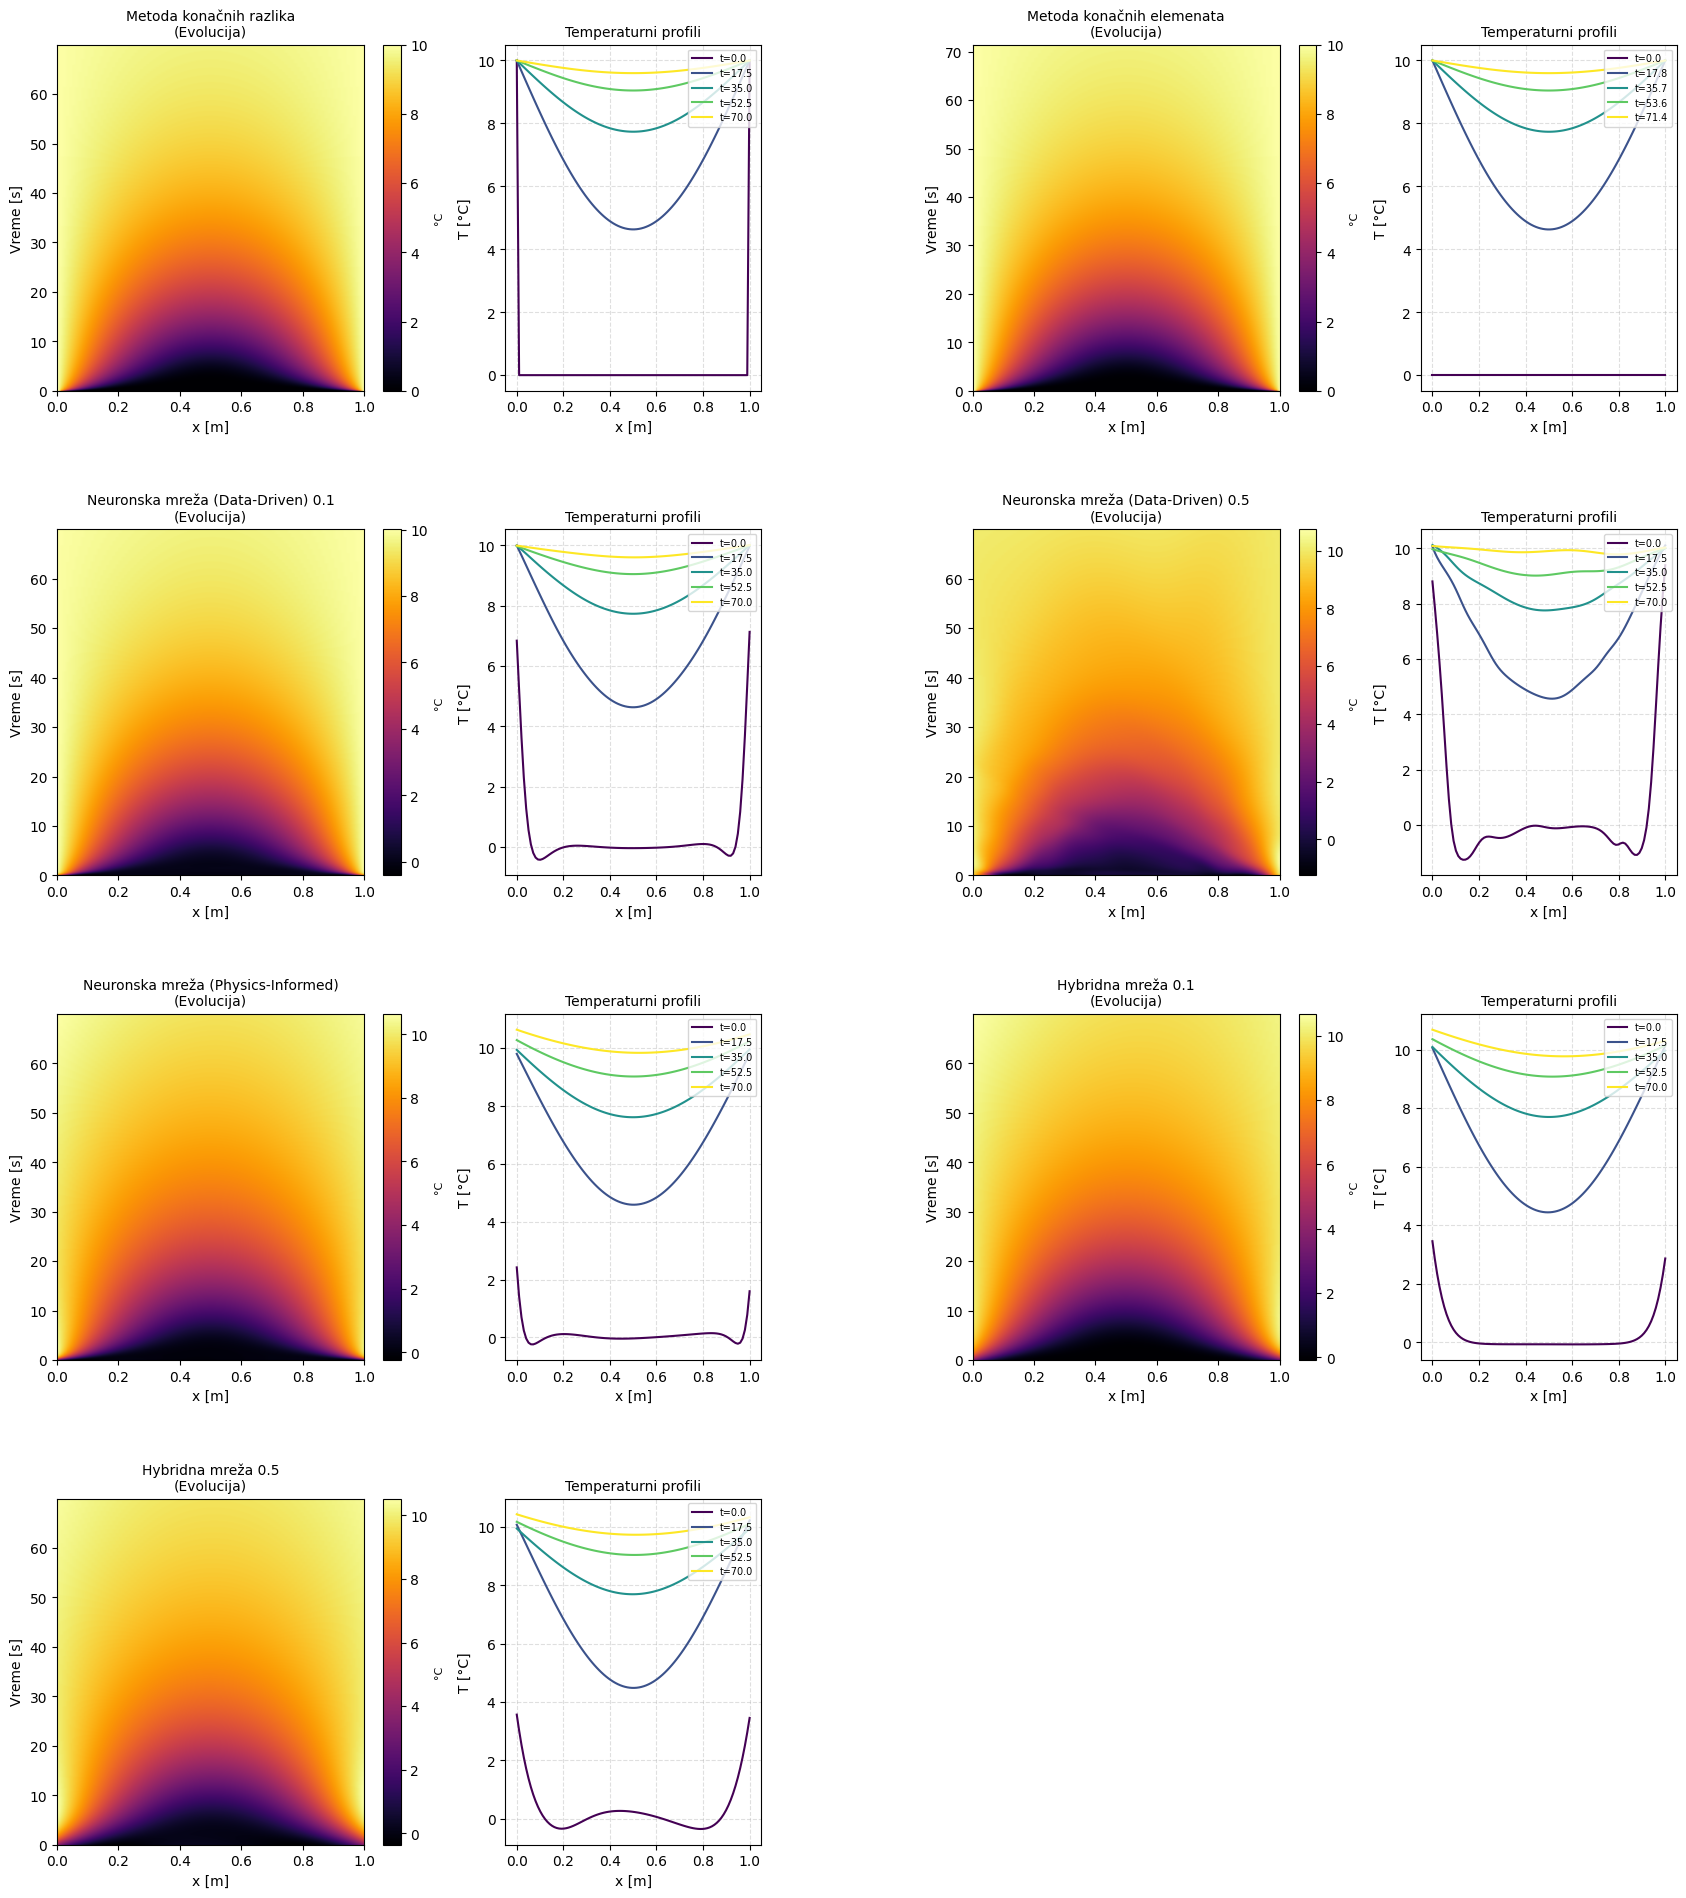

In [21]:
grid_lista = [metodaKonacnihRazlika.T_matrica, metodaKonacnihElemenata.T_matrica, T1,T2, T3, T4, T5]
naslovi = ["Metoda konačnih razlika", "Metoda konačnih elemenata", "Neuronska mreža (Data-Driven) 0.1","Neuronska mreža (Data-Driven) 0.5", "Neuronska mreža (Physics-Informed)", "Hybridna mreža 0.1", "Hybridna mreža 0.5"]
vizuelizuj_grid_temperatura(grid_lista, naslovi=naslovi, redova=4, kolona=2, x=np.linspace(0, L, 100), dt=metodaKonacnihRazlika.dt, L=L, putanja_do_cuvanja="poredjenje_simulacija.png")


### 5.3 Grafik promene temperature na sredini štapa

Uzvevši u obzir da je red greške numeričkih metoda znatno manji od reda greške svih metoda zasnovanih na neuronskoj mreži, vizuelizovaćemo na zasebnim graficima odstupanja numeričkih metoda i metoda podržanih neuronskim mrežama.

Prvo ćemo iscrtati grafik neuronskih metode.

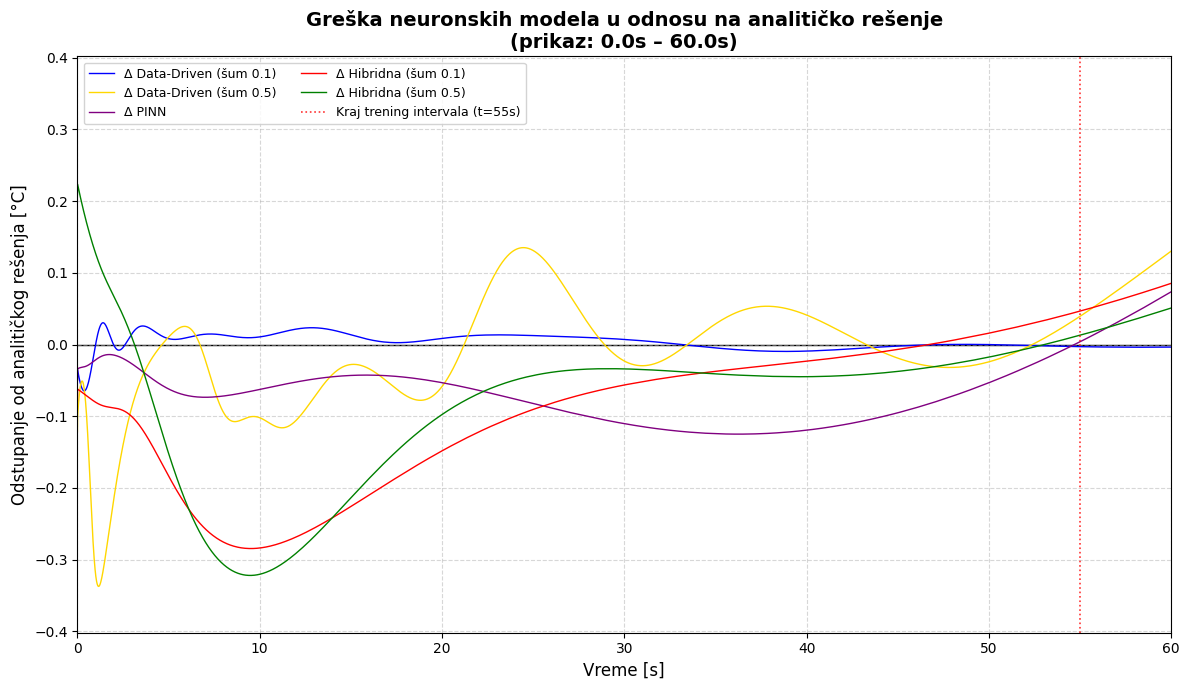

In [41]:
vizuelizuj_vrednosti_na_sredini(metodaKonacnihRazlika, metodaKonacnihElemenata,
                                T1, T2, T3, T4, T5, crtajNumericke=False,
                                tMin=0, tMax_prikaz=60,
                                label="Greška neuronskih modela u odnosu na analitičko rešenje")

Sada ćemo vizuelizovati odstupanja numeričkih metoda u odnosu na analitičko rešenje.

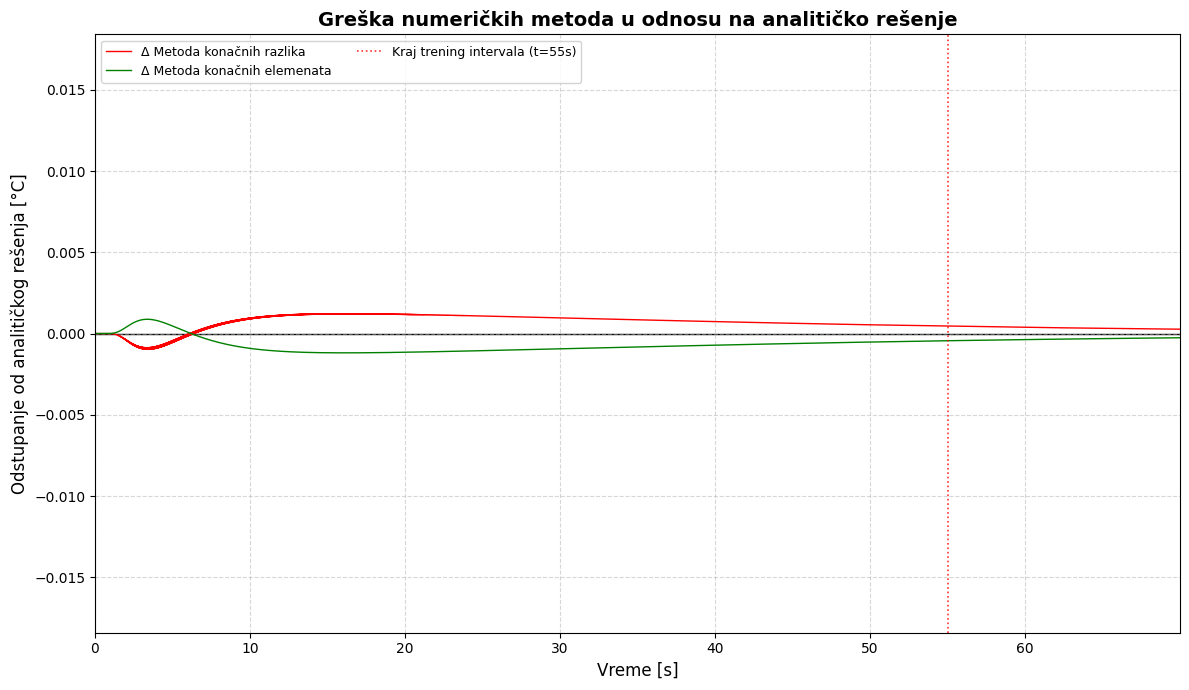

In [40]:
vizuelizuj_vrednosti_na_sredini(metodaKonacnihRazlika, metodaKonacnihElemenata,
                                label="Greška numeričkih metoda u odnosu na analitičko rešenje")

## 6 Analiza

### 6.1 Analiza mape promene temperature

Kao što vidimo, numeričke metode su jedine u potpunosti ispoštovale granični i početni uslov, sve metode zasnovane na neuronskim mrežama su najveće probleme imale i prvom delu simulacije (zbog drastične razlike temperature na krajevima i temperature u ostatku štapa).
Nauronska mreža koja je zasnovana samo na podacima je za podatke sa niskim šumom izvršila dobru generalizaciju i dobila rešenje približno isto kao i numeričke metode. Ipak, sa porastom šuma (koji je moguć u realnim sistemima) klasična neuronska mreža nije uspela da ispoštuje elementarna pravila, pa u prvom momentu štap ima neopravdan skok temperature na sredini.

Fizički informisana neuronska mreža se je pokazala rezultate slične numerički dobijenim rezultatima, čak i za period o kojem nije imala informacije u procesu treniranja pokazuje logične rezultate.
Primećujemo da fizički informisana neuronska mreža u kombinaciji sa prikupljenim podacima znatno bolje absorbuje šum i daje povoljan rezultat čak i sa relativno nekonzistentnim podacima.

### 6.2 Analiza promene temperature na sredini štapa

Na osnovu grafika odstupanja na sredini štapa, mogu se izvući sledeći zaključci:

Primećujemo da za pojednostavljen oblik (jednodimenzionalni štap) metoda konačnih elemenata i metoda konačnih razlika daju rešenja sa relativno istim nivoom greške. Ipak po debljini linije primećujemo da metoda konačnih razlika poseduje mnogo veći broj neopravdanih oscilacija (moguće zato što je uslov stabilnosti na samoj granici). Kako vreme prolazi i sistem se bliži svojem stabilnom obliku, obe metode se približavaju analitičkom rešenju.

Data-Driven modeli i šum - Model sa nižim nivoom šuma (0.1) pokazuje izuzetnu preciznost, dok model sa višim šumom (0.5) teže postiže stabilnost u inicijalnom periodu. Ipak, nakon prolaska prelaznog režima, oba modela konvergiraju ka sličnim vrednostima.

PINN i hibridni modeli - Fizički informisana neuronska mreža (PINN) striktno prati zakone termodinamike, ali i dalje pokazuje blago početno odstupanje zbog "kolizije" graničnih i početnih uslova na samom startu. Hibridni modeli su se pokazali kao najrobustniji, kombinujući brzinu prilagođavanja data-driven metoda sa fizičkom konzistentnošću PINN-a.
U periodu nakon 55s, svi modeli zasnovani na neuronskim mrežama otpočinju odstupanje od analitičkog rešenja, primećujemo da je kod svih metoda zasnovanih na fizici to odstupanje manje u odnosu na metode zasnovane samo na podacima.